In [1]:
import os
from dotenv import load_dotenv
from googleapiclient.discovery import build

# Load API key from .env file - never hardcode secrets in code!
load_dotenv()
api_key = os.getenv('YOUTUBE_API_KEY')

# Connect to YouTube API
youtube = build('youtube', 'v3', developerKey=api_key)

print("Connected to YouTube API!")

Connected to YouTube API!


In [2]:
# Search for videos about luxury fashion shows
search_response = youtube.search().list(
    q='Prada Miu Miu Gucci fashion show 2024',
    part='id,snippet',
    maxResults=5,
    type='video'
).execute()

# Print video titles and IDs
for item in search_response['items']:
    print(item['snippet']['title'])
    print(item['id']['videoId'])
    print('---')

Miu Miu | Spring/Summer 2024 Fashion Show
dFbMGgBAaI4
---
Miu Miu | Spring/Summer 2026 Fashion Show
lTyjzLc-gxg
---
Miuccia Prada and Raf Simons present Prada SS24 Womenswear Collection
DdmvSaakQEo
---
Miuccia Prada and Raf Simons present Prada FW24 Womenswear Collection
N9jTwNiSj6U
---
Gucci | Fall Winter 2023/2024 | Full Show
FBwbQCLD6WE
---


In [3]:
# Store video IDs with brand names
videos = {
    'Miu Miu SS24': 'dFbMGgBAaI4',
    'Miu Miu SS26': 'lTyjzLc-gxg',
    'Prada SS24': 'DdmvSaakQEo',
    'Prada FW24': 'N9jTwNiSj6U',
    'Gucci FW23': 'FBwbQCLD6WE'
}

# Download comments for each video
all_comments = []

for video_name, video_id in videos.items():
    print(f"Downloading comments for {video_name}...")
    
    response = youtube.commentThreads().list(
        part='snippet',
        videoId=video_id,
        maxResults=100,
        textFormat='plainText'
    ).execute()
    
    for item in response['items']:
        comment = item['snippet']['topLevelComment']['snippet']['textDisplay']
        all_comments.append({
            'video': video_name,
            'comment': comment
        })

print(f"\nTotal comments downloaded: {len(all_comments)}")


Total comments downloaded: 425


In [4]:
import pandas as pd
from textblob import TextBlob

In [5]:
# Convert list to a table
df_comments = pd.DataFrame(all_comments)

# Analyze sentiment for each comment
def analyze_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    
    # polarity is a number between -1 and 1
    # -1 = very negative, 0 = neutral, 1 = very positive
    if polarity > 0.1:
        return 'positive'
    elif polarity < -0.1:
        return 'negative'
    else:
        return 'neutral'

# Apply sentiment analysis to every comment
df_comments['sentiment'] = df_comments['comment'].apply(analyze_sentiment)
df_comments['polarity'] = df_comments['comment'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Preview
print(df_comments.head(10))

          video                                            comment sentiment  \
0  Miu Miu SS24                      Love the music to this runway  positive   
1  Miu Miu SS24                                             Super!  positive   
2  Miu Miu SS24                   Para o.mundo que eu quero descer   neutral   
3  Miu Miu SS24  WTF, only things that were nice are begs and h...   neutral   
4  Miu Miu SS24                                        조민지가 먼저 잘게요   neutral   
5  Miu Miu SS24                                  Marianna 😂😂😂야옹이.응   neutral   
6  Miu Miu SS24                                               7:54   neutral   
7  Miu Miu SS24             All models look pissed off and grumpy.   neutral   
8  Miu Miu SS24                         Teacher sohee crazy😮 ya ya   neutral   
9  Miu Miu SS24   Qween we r no tta no worrior 😊❤❤❤yes yes 😊😊😊mz .   neutral   

   polarity  
0  0.500000  
1  0.416667  
2  0.000000  
3 -0.013333  
4  0.000000  
5  0.000000  
6  0.000000  
7  0.00

In [6]:
# Count sentiment per video
summary = df_comments.groupby(['video', 'sentiment']).size().unstack(fill_value=0)

print(summary)

sentiment     negative  neutral  positive
video                                    
Gucci FW23           4       15         6
Miu Miu SS24         6       68        26
Miu Miu SS26        10       64        26
Prada FW24           8       63        29
Prada SS24           6       67        27


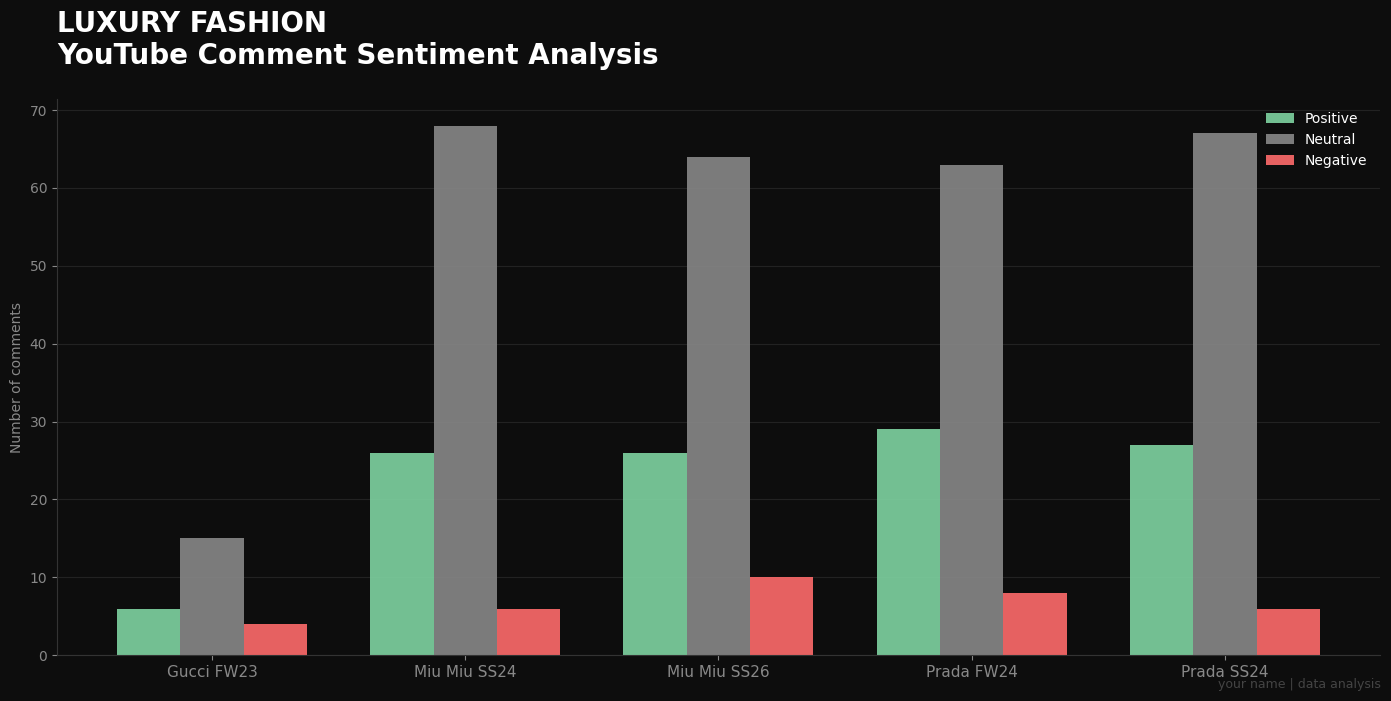

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Dark elegant style - consistent with our previous chart
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0D0D0D')
ax.set_facecolor('#0D0D0D')

# Bar positions
videos = summary.index
x = np.arange(len(videos))
width = 0.25

# Draw bars for each sentiment
bars1 = ax.bar(x - width, summary['positive'], width, label='Positive', color='#7FD4A1', alpha=0.9)
bars2 = ax.bar(x, summary['neutral'], width, label='Neutral', color='#888888', alpha=0.9)
bars3 = ax.bar(x + width, summary['negative'], width, label='Negative', color='#FF6B6B', alpha=0.9)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(videos, color='white', fontsize=11)
ax.set_ylabel('Number of comments', color='#888888')
ax.set_title('LUXURY FASHION\nYouTube Comment Sentiment Analysis', 
             fontsize=20, 
             color='white',
             fontweight='bold',
             pad=25,
             loc='left')

# Clean up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.tick_params(colors='#888888')
ax.yaxis.grid(True, color='#222222', linewidth=0.8)
ax.set_axisbelow(True)

# Legend
ax.legend(frameon=False, labelcolor='white')

# Watermark
fig.text(0.99, 0.01, 'your name | data analysis', 
         ha='right', color='#444444', fontsize=9)

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=300, bbox_inches='tight', facecolor='#0D0D0D')
plt.show()